In [25]:
#imports 
import os, gc, io, json, random, time, warnings
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#gpu set-up
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.cuda.empty_cache()
    gc.collect()


PyTorch : 2.1.2+cu118
CUDA    : True
GPU     : NVIDIA GeForce RTX 2050
VRAM    : 4.3 GB


In [26]:
#configuration
H5_PATH  = r'C:\Users\abida\CNN+LSTM Results\faces_9600_380.h5'
SAVE_DIR = r'C:\Users\abida\CNN+LSTM Results\checkpoints_v3'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE      = 380
N_FRAMES      = 15
BATCH_SIZE    = 4
ACCUM_STEPS   = 4
EPOCHS        = 30
LR            = 1e-4
WEIGHT_DECAY  = 1e-3
DROPOUT       = 0.5
LABEL_SMOOTH  = 0.05
PATIENCE      = 7
WARMUP_EPOCHS = 3
LSTM_HIDDEN   = 256
LSTM_LAYERS   = 2
ATTENTION_DIM = 128
NUM_WORKERS   = 0
PIN_MEMORY    = False
MIXED_PREC    = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.cuda.empty_cache()
gc.collect()

print(f'Device         : {DEVICE}')
print(f'IMG_SIZE       : {IMG_SIZE}px   N_FRAMES: {N_FRAMES}')
print(f'BATCH_SIZE     : {BATCH_SIZE}   ACCUM_STEPS: {ACCUM_STEPS}')
print(f'Effective batch: {BATCH_SIZE * ACCUM_STEPS}')
print(f'LSTM hidden    : {LSTM_HIDDEN}  DROPOUT: {DROPOUT}')
print(f'LABEL_SMOOTH   : {LABEL_SMOOTH}')
print(f'H5 exists      : {os.path.exists(H5_PATH)}')


Device         : cuda
IMG_SIZE       : 380px   N_FRAMES: 15
BATCH_SIZE     : 4   ACCUM_STEPS: 4
Effective batch: 16
LSTM hidden    : 256  DROPOUT: 0.5
LABEL_SMOOTH   : 0.05
H5 exists      : True


H5 VERIFICATION
Keys      : ['faces', 'labels', 'methods', 'paths']
Faces     : (9600, 15, 380, 380, 3)  dtype=float16
Valid     : 8891
Balance   : 4374 real  |  4517 fake
Value range: -2.1016 to 1.7354
OK: ImageNet-normalized range confirmed.


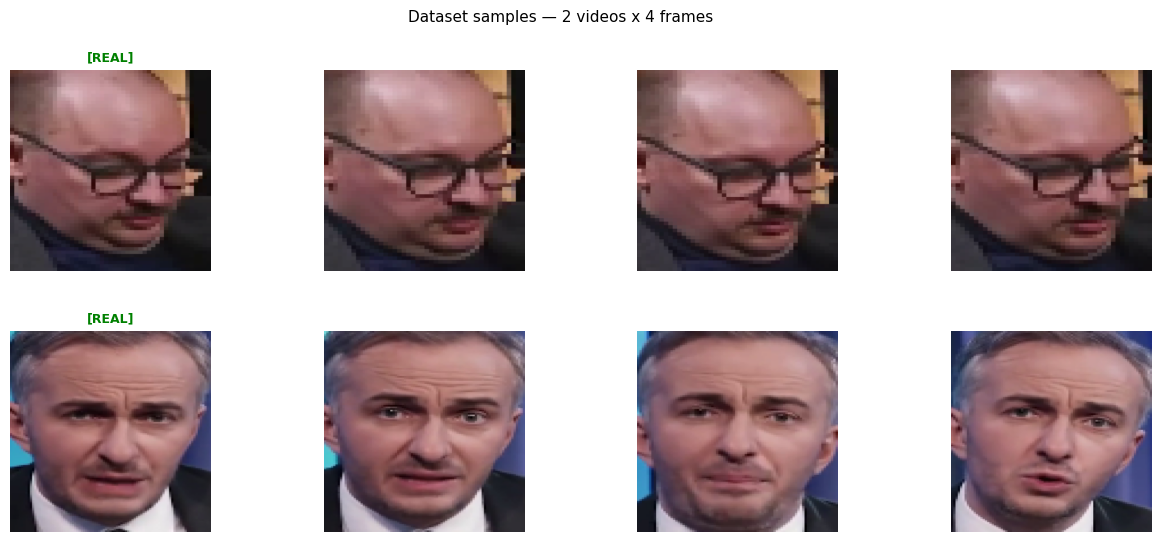

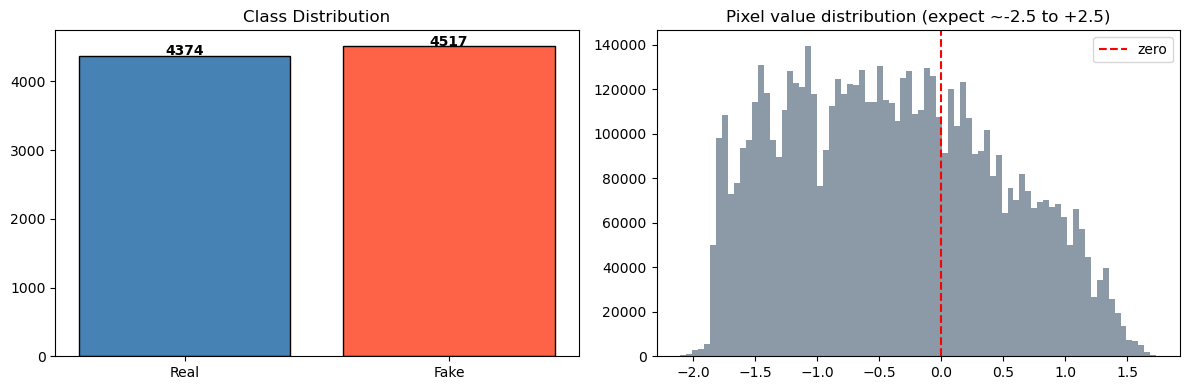

26339

In [3]:
# h5 verification and dataset visualization

MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
MEAN_NP = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD_NP  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def denorm_tensor(t):
    return (t * STD_T + MEAN_T).clamp(0, 1)


def renorm_tensor(t):
    return (t - MEAN_T) / STD_T


def verify_h5(path, save_dir):
    print('=' * 60)
    print('H5 VERIFICATION')
    print('=' * 60)
    with h5py.File(path, 'r') as hf:
        n_valid = int(hf.attrs.get('n_valid', hf['labels'].shape[0]))
        labels  = hf['labels'][:n_valid].astype(int)
        n_real  = int((labels == 0).sum())
        n_fake  = int((labels == 1).sum())
        shape   = hf['faces'].shape
        dtype   = hf['faces'].dtype
        print(f'Keys      : {list(hf.keys())}')
        print(f'Faces     : {shape}  dtype={dtype}')
        print(f'Valid     : {n_valid}')
        print(f'Balance   : {n_real} real  |  {n_fake} fake')
        sample = hf['faces'][0].astype(np.float32)
        vmin, vmax = float(sample.min()), float(sample.max())
        print(f'Value range: {vmin:.4f} to {vmax:.4f}')
        if vmax < 0.1:
            print('FATAL: Values near zero — double /255 bug. Fix preprocessing.')
        elif vmin >= -0.1 and vmax <= 1.1:
            print('WARNING: Data in [0,1] range — NOT ImageNet normalized. Training will fail.')
        else:
            print('OK: ImageNet-normalized range confirmed.')

        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.3, wspace=0.05)
        frame_picks = [0, 4, 9, 14]
        for row in range(2):
            idx = row
            lbl    = int(hf['labels'][idx])
            frames = hf['faces'][idx].astype(np.float32)
            for col, fi in enumerate(frame_picks):
                ax  = fig.add_subplot(gs[row, col])
                img = np.clip(frames[fi] * STD_NP + MEAN_NP, 0, 1)
                ax.imshow(img)
                ax.axis('off')
                if col == 0:
                    color = 'red' if lbl == 1 else 'green'
                    tag   = 'FAKE' if lbl == 1 else 'REAL'
                    ax.set_title(f'[{tag}]', fontsize=9, color=color, fontweight='bold')

        plt.suptitle('Dataset samples — 2 videos x 4 frames', fontsize=11)
        plt.savefig(os.path.join(save_dir, 'dataset_samples.png'), dpi=100, bbox_inches='tight')
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].bar(['Real', 'Fake'], [n_real, n_fake], color=['steelblue', 'tomato'], edgecolor='black')
        axes[0].set_title('Class Distribution')
        for i, v in enumerate([n_real, n_fake]):
            axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
        axes[1].hist(sample.flatten(), bins=80, color='slategray', alpha=0.8)
        axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='zero')
        axes[1].set_title('Pixel value distribution (expect ~-2.5 to +2.5)')
        axes[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'dataset_stats.png'), dpi=100, bbox_inches='tight')
        plt.show()
        print('=' * 60)
        return n_valid, n_real, n_fake, labels


N_VALID, N_REAL, N_FAKE, ALL_LABELS = verify_h5(H5_PATH, SAVE_DIR)
torch.cuda.empty_cache()
gc.collect()


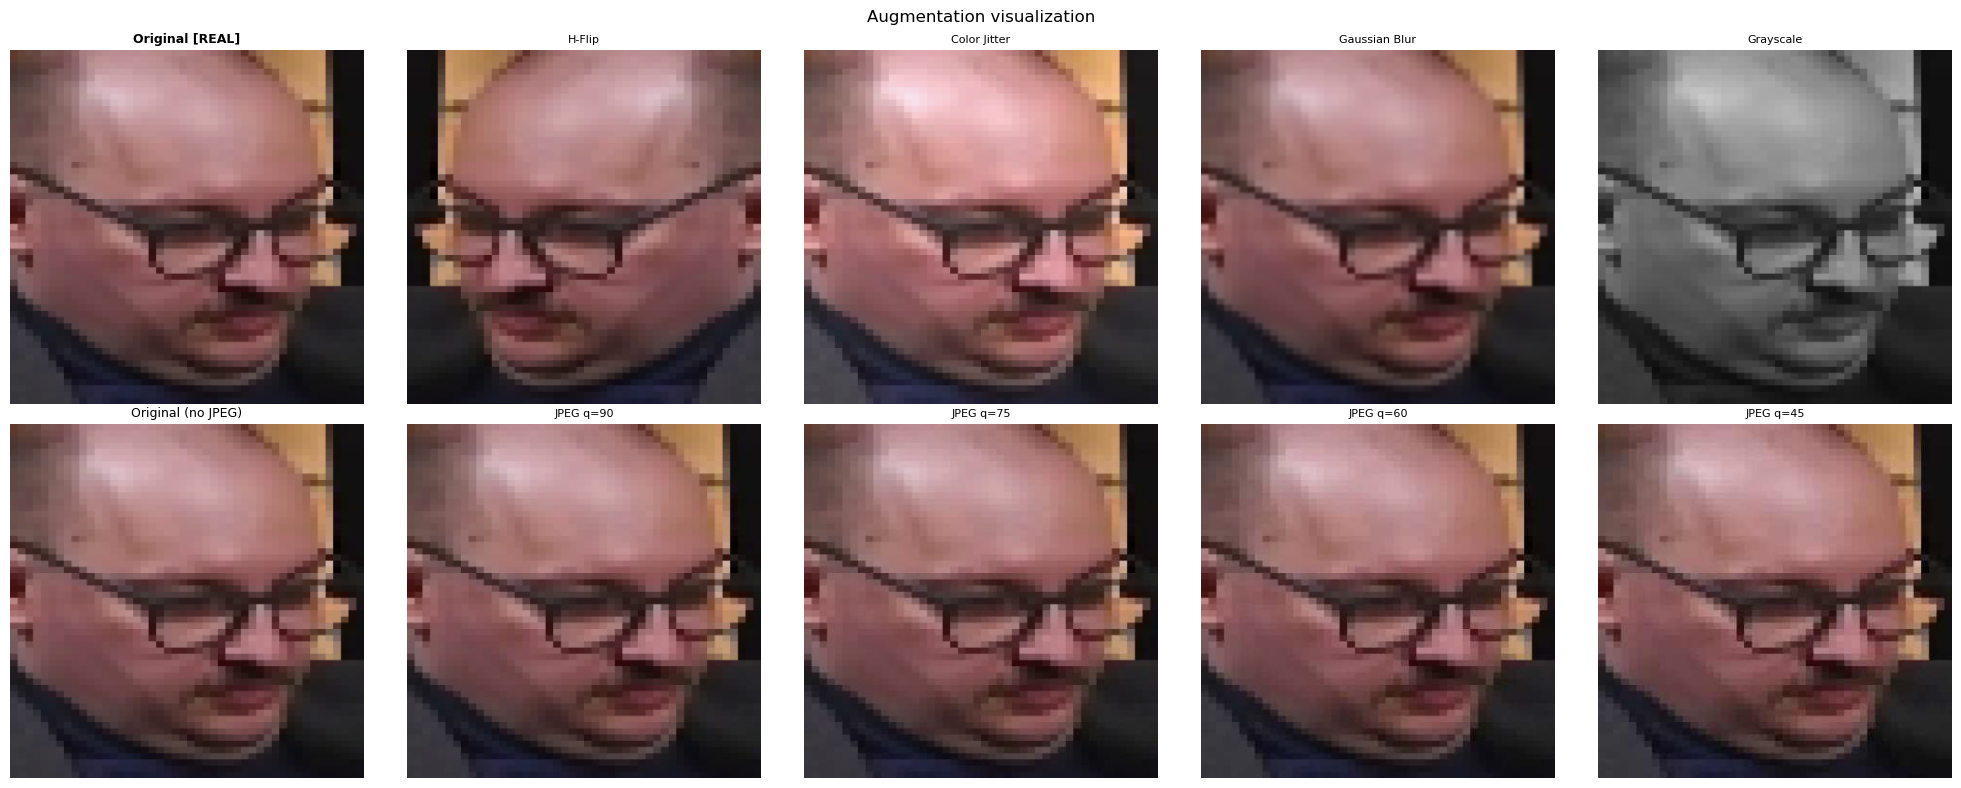

26987

In [4]:
# augmentation visualization

def jpeg_compress_tensor(t, quality_range=(50, 95)):
    quality = random.randint(*quality_range)
    arr = (t.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    out = np.array(Image.open(buf)).astype(np.float32) / 255.0
    return torch.from_numpy(out).permute(2, 0, 1)


SPATIAL_AUG = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.3),
    transforms.RandomGrayscale(p=0.05),
])


def visualize_augmentations(h5_path, save_dir):
    with h5py.File(h5_path, 'r') as hf:
        raw = hf['faces'][0].astype(np.float32)
        lbl = int(hf['labels'][0])
    frame = torch.from_numpy(raw[7]).permute(2, 0, 1)
    img_01 = denorm_tensor(frame)
    tag = 'FAKE' if lbl == 1 else 'REAL'

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes[0, 0].imshow(img_01.permute(1, 2, 0).numpy())
    axes[0, 0].set_title(f'Original [{tag}]', fontsize=9, fontweight='bold')
    axes[0, 0].axis('off')

    aug_labels = ['H-Flip', 'Color Jitter', 'Gaussian Blur', 'Grayscale']
    augs = [
        transforms.functional.hflip,
        lambda x: transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15)(x),
        lambda x: transforms.GaussianBlur(kernel_size=5, sigma=1.0)(x),
        lambda x: transforms.functional.rgb_to_grayscale(x, num_output_channels=3),
    ]
    for col, (aug, name) in enumerate(zip(augs, aug_labels)):
        x = aug(img_01.clone())
        axes[0, col + 1].imshow(x.permute(1, 2, 0).numpy())
        axes[0, col + 1].set_title(name, fontsize=8)
        axes[0, col + 1].axis('off')

    axes[1, 0].imshow(img_01.permute(1, 2, 0).numpy())
    axes[1, 0].set_title('Original (no JPEG)', fontsize=9)
    axes[1, 0].axis('off')
    for col, q in enumerate([90, 75, 60, 45]):
        j = jpeg_compress_tensor(img_01.clone(), quality_range=(q, q))
        axes[1, col + 1].imshow(j.permute(1, 2, 0).numpy())
        axes[1, col + 1].set_title(f'JPEG q={q}', fontsize=8)
        axes[1, col + 1].axis('off')

    plt.suptitle('Augmentation visualization', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'augmentation_viz.png'), dpi=100, bbox_inches='tight')
    plt.show()


visualize_augmentations(H5_PATH, SAVE_DIR)
torch.cuda.empty_cache()
gc.collect()


In [27]:
# dataset class

class DeepfakeDataset(Dataset):

    def __init__(self, h5_path, indices, augment=False):
        self.h5_path = h5_path
        self.indices = list(indices)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = self.indices[item]
        with h5py.File(self.h5_path, 'r') as hf:
            faces = hf['faces'][idx].astype(np.float32)
            label = int(hf['labels'][idx])

        frames = []
        for i in range(N_FRAMES):
            frame = np.clip(faces[i], -3.5, 3.5)
            if not np.isfinite(frame).all():
                frame = np.zeros_like(frame)
            t = torch.from_numpy(frame).permute(2, 0, 1)

            if self.augment:
                img_01 = denorm_tensor(t)
                img_01 = SPATIAL_AUG(img_01)
                if random.random() < 0.5:
                    img_01 = jpeg_compress_tensor(img_01, quality_range=(50, 95))
                t = renorm_tensor(img_01)

            frames.append(t)

        if self.augment and random.random() < 0.25:
            n_drop = random.randint(1, 2)
            for di in random.sample(range(N_FRAMES), n_drop):
                frames[di] = torch.zeros(3, IMG_SIZE, IMG_SIZE)

        seq = torch.stack(frames, dim=0)
        return seq, torch.tensor(label, dtype=torch.float32)


print('DeepfakeDataset defined.')


DeepfakeDataset defined.


In [28]:
# model architecture

class TemporalAttention(nn.Module):

    def __init__(self, hidden_dim, attention_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1, bias=False)
        )

    def forward(self, lstm_out):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        context = (lstm_out * weights).sum(dim=1)
        return context, weights.squeeze(-1)


class DeepfakeDetector(nn.Module):

    def __init__(self):
        super().__init__()
        backbone  = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.cnn  = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        cnn_out   = 1792

        for p in self.cnn.parameters():
            p.requires_grad = False
        for p in self.cnn[-3:].parameters():
            p.requires_grad = True

        total     = sum(p.numel() for p in self.cnn.parameters())
        trainable = sum(p.numel() for p in self.cnn.parameters() if p.requires_grad)
        print(f'CNN trainable: {trainable:,} / {total:,}  ({trainable/total:.1%})')

        self.cnn_drop   = nn.Dropout(0.2)
        self.frame_proj = nn.Sequential(
            nn.Linear(cnn_out, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(0.3)
        )
        self.bilstm = nn.LSTM(
            input_size=512,
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT if LSTM_LAYERS > 1 else 0.0
        )
        self.attention  = TemporalAttention(LSTM_HIDDEN, ATTENTION_DIM)
        self.classifier = nn.Sequential(
            nn.Linear(LSTM_HIDDEN * 2, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.bilstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
        for m in [*self.frame_proj, *self.classifier]:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_flat = x.contiguous().view(B * T, C, H, W)
        if self.training:
            feats = checkpoint(self.cnn, x_flat, use_reentrant=False)
        else:
            with torch.no_grad():
                feats = self.cnn(x_flat)
        feats    = self.pool(feats).view(B * T, -1)
        feats    = self.cnn_drop(feats)
        feats    = feats.view(B, T, -1)
        feats    = self.frame_proj(feats)
        lstm_out, _ = self.bilstm(feats)
        context, attn_weights = self.attention(lstm_out)
        logit = self.classifier(context).squeeze(-1)
        return logit, attn_weights


print('Building model...')
model       = DeepfakeDetector().to(DEVICE)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_p:,}')
print(f'Trainable params: {trainable_p:,}')
torch.cuda.empty_cache()
gc.collect()
if torch.cuda.is_available():
    print(f'GPU mem after load: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Building model...
CNN trainable: 13,912,632 / 17,548,616  (79.3%)
Total params    : 21,753,417
Trainable params: 18,117,433
GPU mem after load: 0.59 GB


In [29]:
# data split and dataloaders
all_indices = np.arange(N_VALID)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_indices, ALL_LABELS, test_size=0.20, stratify=ALL_LABELS, random_state=42
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train : {len(train_idx)}  ({(y_train==1).sum()} fake | {(y_train==0).sum()} real)')
print(f'Val   : {len(val_idx)}   ({(y_val==1).sum()} fake | {(y_val==0).sum()} real)')
print(f'Test  : {len(test_idx)}  ({(y_test==1).sum()} fake | {(y_test==0).sum()} real)')

class_counts   = np.bincount(y_train)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_idx),
    replacement=True
)

train_ds = DeepfakeDataset(H5_PATH, train_idx, augment=True)
val_ds   = DeepfakeDataset(H5_PATH, val_idx,   augment=False)
test_ds  = DeepfakeDataset(H5_PATH, test_idx,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches: {len(train_loader)}')

sx, sy = next(iter(train_loader))
print(f'Batch shape : {sx.shape}')
print(f'Value range : {sx.min():.3f} to {sx.max():.3f}')
assert sx.abs().max() > 0.5, 'FATAL: values near zero — data range wrong.'
print('Sanity check passed.')
del sx, sy
torch.cuda.empty_cache()
gc.collect()


Train : 7112  (3613 fake | 3499 real)
Val   : 889   (452 fake | 437 real)
Test  : 890  (452 fake | 438 real)
Train batches: 1778
Batch shape : torch.Size([4, 15, 3, 380, 380])
Value range : -2.118 to 2.640
Sanity check passed.


49

In [30]:
# loss function , optimizer , scheduler
class LabelSmoothBCE(nn.Module):

    def __init__(self, smoothing=0.05, pos_weight=None):
        super().__init__()
        self.smoothing  = smoothing
        self.bce        = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        smooth = targets * (1.0 - self.smoothing) + self.smoothing * 0.5
        return self.bce(logits, smooth)


n_fake_tr  = int((y_train == 1).sum())
n_real_tr  = int((y_train == 0).sum())
pos_weight = torch.tensor([n_real_tr / n_fake_tr], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.4f}')

criterion = LabelSmoothBCE(smoothing=LABEL_SMOOTH, pos_weight=pos_weight)

backbone_params = [p for p in model.cnn.parameters() if p.requires_grad]
head_params = (
    list(model.frame_proj.parameters()) +
    list(model.bilstm.parameters())     +
    list(model.attention.parameters())  +
    list(model.classifier.parameters()) +
    list(model.cnn_drop.parameters())
)

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR}
], weight_decay=WEIGHT_DECAY)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + np.cos(np.pi * t))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=MIXED_PREC)

print(f'Backbone LR : {LR * 0.1:.2e}')
print(f'Head LR     : {LR:.2e}')


pos_weight: 0.9684
Backbone LR : 1.00e-05
Head LR     : 1.00e-04


In [31]:
# training and evaluation functions

def mixup_batch(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]


def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss = 0.0
    correct = 0
    total   = 0
    all_probs = []
    all_lbls  = []

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f'Ep{epoch:02d} Train', leave=False, dynamic_ncols=True)

    for step, (x, y) in enumerate(pbar):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if torch.isnan(x).any():
            continue

        if random.random() < 0.3:
            x, y_mix = mixup_batch(x, y, alpha=0.3)
        else:
            y_mix = y

        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logits, _ = model(x)
            if torch.isnan(logits).any():
                continue
            loss = criterion(logits, y_mix) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            probs = torch.sigmoid(logits.detach())
            preds = (probs > 0.5).float()
            correct    += (preds == y).sum().item()
            total      += y.size(0)
            total_loss += loss.item() * ACCUM_STEPS * y.size(0)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_lbls.extend(y.cpu().numpy().tolist())

        if (step + 1) % 50 == 0:
            torch.cuda.empty_cache()

        pbar.set_postfix({'loss': f'{total_loss/max(total,1):.4f}',
                          'acc':  f'{100*correct/max(total,1):.1f}%'})

    try:
        auc = roc_auc_score(all_lbls, all_probs)
    except Exception:
        auc = 0.5
    return total_loss / max(total, 1), correct / max(total, 1), auc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_probs  = []
    all_lbls   = []

    for x, y in tqdm(loader, desc='Val', leave=False, dynamic_ncols=True):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if torch.isnan(x).any():
            continue

        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logits, _ = model(x)
            if torch.isnan(logits).any():
                continue
            loss = criterion(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        total_loss += loss.item() * y.size(0)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_lbls.extend(y.cpu().numpy().tolist())

    try:
        auc = roc_auc_score(all_lbls, all_probs)
    except Exception:
        auc = 0.5
    return total_loss / max(total, 1), correct / max(total, 1), auc


print('Train and eval functions defined.')


Train and eval functions defined.


In [10]:
# training loop

history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc','lr']}

best_val_auc   = 0.0
patience_count = 0
best_ckpt      = os.path.join(SAVE_DIR, 'best_model.pth')

print('Starting training')
print('=' * 70)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_t = time.time()

    tr_loss, tr_acc, tr_auc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, epoch
    )

    torch.cuda.empty_cache()
    gc.collect()

    vl_loss, vl_acc, vl_auc = evaluate(model, val_loader, criterion)

    scheduler.step()
    current_lr = optimizer.param_groups[-1]['lr']

    for k, v in zip(
        ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc','lr'],
        [tr_loss, vl_loss, tr_acc, vl_acc, tr_auc, vl_auc, current_lr]
    ):
        history[k].append(v)

    ep_min = (time.time() - ep_t) / 60

    print(f'Epoch {epoch:03d}/{EPOCHS}  |  LR: {current_lr:.2e}  |  {ep_min:.1f} min'
          f'  |  Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  AUC: {tr_auc:.4f}'
          f'  |  Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%  AUC: {vl_auc:.4f}')

    if vl_auc > best_val_auc:
        best_val_auc   = vl_auc
        best_epoch     = epoch
        best_tr_loss   = tr_loss
        best_tr_acc    = tr_acc
        best_tr_auc    = tr_auc
        best_vl_loss   = vl_loss
        best_vl_acc    = vl_acc
        patience_count = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'val_auc':     vl_auc,
            'val_acc':     vl_acc,
            'train_auc':   tr_auc,
            'train_acc':   tr_acc,
        }, best_ckpt)
    else:
        patience_count += 1

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

    torch.cuda.empty_cache()
    gc.collect()

total_min = (time.time() - t_start) / 60
auc_gap   = best_tr_auc - best_val_auc

if auc_gap > 0.20:
    final_status = 'Overfitting — val AUC significantly below train'
elif auc_gap < 0.10:
    final_status = 'Good generalization — train and val AUC close'
else:
    final_status = 'Mild overfitting — acceptable for this dataset size'

print('\n' + '=' * 70)
print('TRAINING COMPLETE')
print('=' * 70)
print(f'Total time        : {total_min:.1f} min')
print(f'Best epoch        : {best_epoch}')
print(f'Train Loss        : {best_tr_loss:.4f}')
print(f'Train Accuracy    : {best_tr_acc*100:.2f}%')
print(f'Train AUC         : {best_tr_auc:.4f}')
print(f'Val Loss          : {best_vl_loss:.4f}')
print(f'Val Accuracy      : {best_vl_acc*100:.2f}%')
print(f'Val AUC           : {best_val_auc:.4f}')
print(f'AUC Gap           : {auc_gap:+.4f}')
print(f'Generalization    : {final_status}')
print(f'Best checkpoint   : {best_ckpt}')
print('=' * 70)

Starting training


Epoch 001/30  |  LR: 6.67e-05  |  118.2 min  |  Train Loss: 0.6292  Acc: 62.99%  AUC: 0.6779  |  Val Loss: 0.5291  Acc: 73.45%  AUC: 0.8250


Epoch 002/30  |  LR: 1.00e-04  |  117.9 min  |  Train Loss: 0.5699  Acc: 68.22%  AUC: 0.7406  |  Val Loss: 0.5080  Acc: 74.13%  AUC: 0.8631


Epoch 003/30  |  LR: 1.00e-04  |  118.0 min  |  Train Loss: 0.5280  Acc: 72.06%  AUC: 0.7849  |  Val Loss: 0.5275  Acc: 73.57%  AUC: 0.8706


Epoch 004/30  |  LR: 9.97e-05  |  117.9 min  |  Train Loss: 0.5051  Acc: 73.69%  AUC: 0.8072  |  Val Loss: 0.5781  Acc: 78.52%  AUC: 0.8813


...

Epoch 018/30  |  LR: 4.13e-05  |  118.4 min  |  Train Loss: 0.4146  Acc: 79.75%  AUC: 0.8750  |  Val Loss: 0.4091  Acc: 86.05%  AUC: 0.9162


Epoch 019/30  |  LR: 3.57e-05  |  120.6 min  |  Train Loss: 0.3992  Acc: 80.82%  AUC: 0.8832  |  Val Loss: 0.4045  Acc: 84.48%  AUC: 0.9143


Epoch 020/30  |  LR: 3.02e-05  |  120.6 min  |  Train Loss: 0.3996  Acc: 80.39%  AUC: 0.8768  |  Val Loss: 0.4408  Acc: 84.48%  AUC: 0.9152


Epoch 021/30  |  LR: 2.50e-05  |  118.6 min  |  Train Loss: 0.3855  Acc: 81.62%  AUC: 0.8881  |  Val Loss: 0.4299  Acc: 84.93%  AUC: 0.9132


Epoch 022/30  |  LR: 2.01e-05  |  118.7 min  |  Train Loss: 0.3990  Acc: 80.79%  AUC: 0.8815  |  Val Loss: 0.4472  Acc: 84.48%  AUC: 0.9145

Early stopping triggered at epoch 22.

TRAINING COMPLETE
Total time        : 2758.0 min
Best epoch        : 15
Train Loss        : 0.4194
Train Accuracy    : 80.37%
Train AUC         : 0.8674
Val Loss          : 0.4200
Val Accuracy      : 84.59%
Val AUC           : 0.9166
AUC Gap           : -0.0493
Generalization    : Good generalization — train and val AUC close
Best checkpoint   : C:\Users\abida\CNN+LSTM Results\checkpoints_v3\best_model.pth


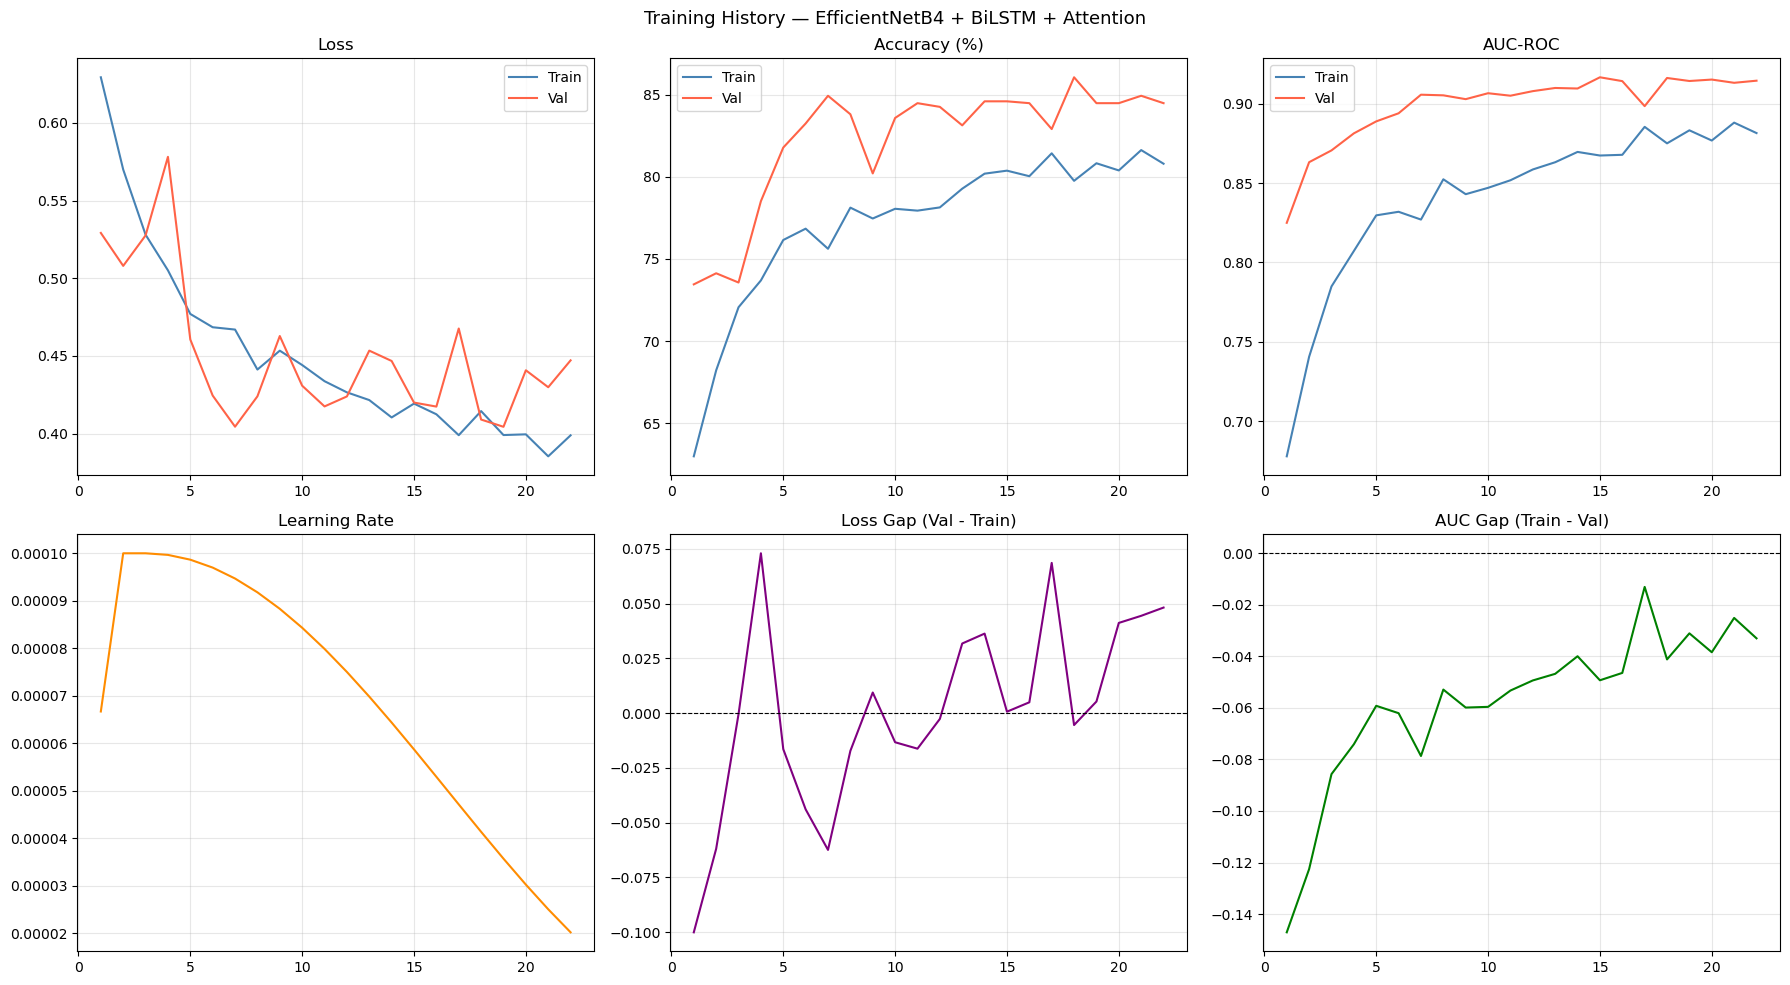

Saved: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\training_curves.png
History saved: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\history.json


In [11]:
# training history plot

def plot_training_history(history, save_dir):
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History — EfficientNetB4 + BiLSTM + Attention', fontsize=13)

    axes[0, 0].plot(ep, history['train_loss'], label='Train', color='steelblue')
    axes[0, 0].plot(ep, history['val_loss'],   label='Val',   color='tomato')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(ep, [v * 100 for v in history['train_acc']], label='Train', color='steelblue')
    axes[0, 1].plot(ep, [v * 100 for v in history['val_acc']],   label='Val',   color='tomato')
    axes[0, 1].set_title('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(ep, history['train_auc'], label='Train', color='steelblue')
    axes[0, 2].plot(ep, history['val_auc'],   label='Val',   color='tomato')
    axes[0, 2].set_title('AUC-ROC')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    axes[1, 0].plot(ep, history['lr'], color='darkorange')
    axes[1, 0].set_title('Learning Rate')
    axes[1, 0].grid(True, alpha=0.3)

    gap_loss = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
    gap_auc  = [t - v for t, v in zip(history['train_auc'],  history['val_auc'])]

    axes[1, 1].plot(ep, gap_loss, color='purple')
    axes[1, 1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1, 1].set_title('Loss Gap (Val - Train)')
    axes[1, 1].grid(True, alpha=0.3)

    axes[1, 2].plot(ep, gap_auc, color='green')
    axes[1, 2].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1, 2].set_title('AUC Gap (Train - Val)')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(save_dir, 'training_curves.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')


plot_training_history(history, SAVE_DIR)

hist_path = os.path.join(SAVE_DIR, 'history.json')
with open(hist_path, 'w') as f:
    json.dump({k: [float(v) for v in vs] for k, vs in history.items()}, f, indent=2)
print(f'History saved: {hist_path}')


Loading: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\best_model.pth
Restored epoch 15  ->  Val AUC: 0.9166


Testing: 100%|███████████████████████████████████████████████████████████████████████| 223/223 [03:54<00:00,  1.05s/it]



FINAL TEST RESULTS
Accuracy  : 83.82%
ROC-AUC   : 0.8955

              precision    recall  f1-score   support

        Real     0.8168    0.8653    0.8404       438
        Fake     0.8615    0.8119    0.8360       452

    accuracy                         0.8382       890
   macro avg     0.8392    0.8386    0.8382       890
weighted avg     0.8395    0.8382    0.8381       890



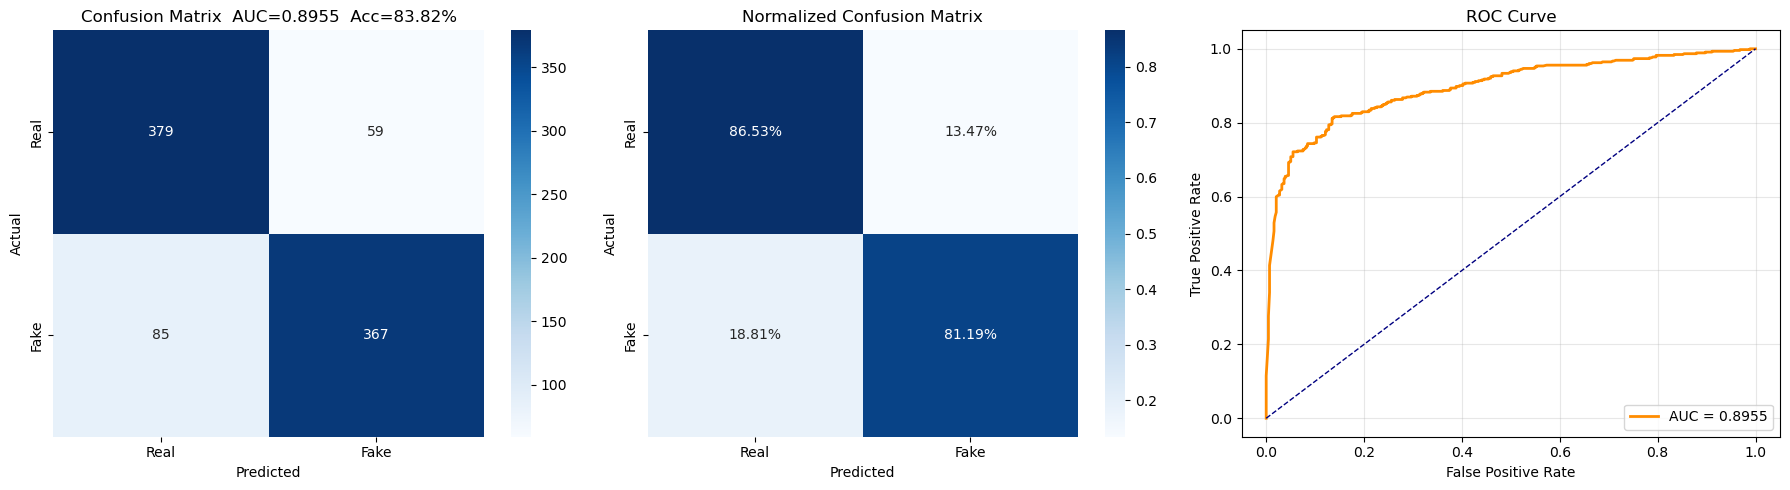

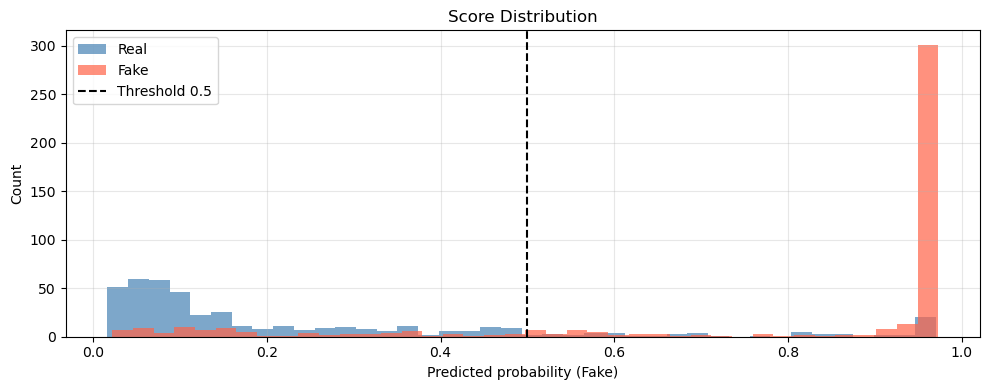

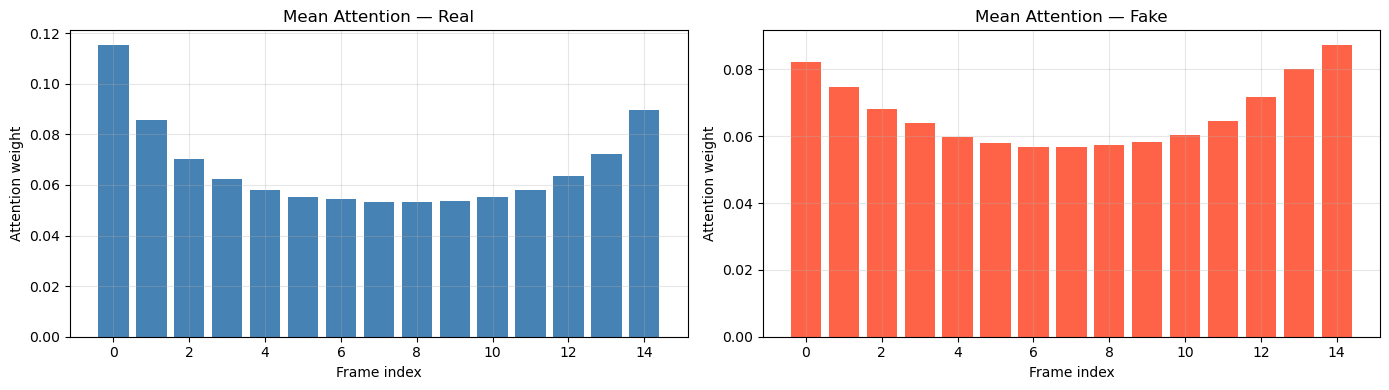

All outputs saved to: C:\Users\abida\CNN+LSTM Results\checkpoints_v3


45251

In [12]:
# test evaluation and visualization

print(f'Loading: {best_ckpt}')
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Restored epoch {ckpt["epoch"]}  ->  Val AUC: {ckpt["val_auc"]:.4f}')

model.eval()
all_probs  = []
all_preds  = []
all_labels = []
all_attns  = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Testing'):
        x = x.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logits, attn_w = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(y.numpy().astype(int).tolist())
        all_attns.extend(attn_w.cpu().numpy().tolist())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_auc = roc_auc_score(all_labels, all_probs)
test_acc = (all_preds == all_labels).mean()

print('\n' + '=' * 55)
print('FINAL TEST RESULTS')
print('=' * 55)
print(f'Accuracy  : {test_acc*100:.2f}%')
print(f'ROC-AUC   : {test_auc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake'], digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix  AUC={test_auc:.4f}  Acc={test_acc*100:.2f}%')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Normalized Confusion Matrix')

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[2].plot(fpr, tpr, color='darkorange', linewidth=2, label=f'AUC = {test_auc:.4f}')
axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'test_results.png'), dpi=130, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_probs[all_labels == 0], bins=40, alpha=0.7, label='Real', color='steelblue')
ax.hist(all_probs[all_labels == 1], bins=40, alpha=0.7, label='Fake', color='tomato')
ax.axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
ax.set_xlabel('Predicted probability (Fake)')
ax.set_ylabel('Count')
ax.set_title('Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'score_distribution.png'), dpi=130)
plt.show()

real_attns = [a for a, l in zip(all_attns, all_labels) if l == 0]
fake_attns = [a for a, l in zip(all_attns, all_labels) if l == 1]
if real_attns and fake_attns:
    mean_attn_real = np.array(real_attns).mean(axis=0)
    mean_attn_fake = np.array(fake_attns).mean(axis=0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, attn, title, color in [
        (axes[0], mean_attn_real, 'Mean Attention — Real', 'steelblue'),
        (axes[1], mean_attn_fake, 'Mean Attention — Fake', 'tomato')
    ]:
        ax.bar(range(N_FRAMES), attn, color=color)
        ax.set_xlabel('Frame index')
        ax.set_ylabel('Attention weight')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'attention_heatmap.png'), dpi=130)
    plt.show()

results = {'test_accuracy': float(test_acc), 'test_auc': float(test_auc),
           'best_epoch': int(ckpt['epoch']), 'best_val_auc': float(ckpt['val_auc'])}
with open(os.path.join(SAVE_DIR, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f'All outputs saved to: {SAVE_DIR}')
torch.cuda.empty_cache()
gc.collect()


In [13]:
# ONXX Export
try:
    import onnx
    import onnxruntime as ort
    HAS_ONNX = True
except ImportError:
    HAS_ONNX = False
    print('Install: pip install onnx onnxruntime')

if HAS_ONNX:
    ONNX_PATH = os.path.join(SAVE_DIR, 'deepfake_detector.onnx')

    class OnnxWrapper(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            logit, _ = self.m(x)
            return logit

    model.eval()
    wrapper = OnnxWrapper(model).to(DEVICE)
    wrapper.eval()
    dummy = torch.randn(1, N_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    with torch.no_grad():
        torch.onnx.export(
            wrapper, dummy, ONNX_PATH,
            input_names=['video_frames'],
            output_names=['logit'],
            dynamic_axes={'video_frames': {0: 'batch'}, 'logit': {0: 'batch'}},
            opset_version=17,
            do_constant_folding=True
        )

    onnx.checker.check_model(onnx.load(ONNX_PATH))
    size_mb = os.path.getsize(ONNX_PATH) / 1e6
    print(f'ONNX saved : {ONNX_PATH}')
    print(f'Size       : {size_mb:.1f} MB')
    print('ONNX check : PASSED')

    sess     = ort.InferenceSession(ONNX_PATH, providers=['CUDAExecutionProvider','CPUExecutionProvider'])
    dummy_np = np.random.randn(1, N_FRAMES, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    ort_out  = sess.run(None, {'video_frames': dummy_np})
    print(f'ORT output shape: {np.array(ort_out).shape}')
    print('ONNX Runtime : PASSED')


ONNX saved : C:\Users\abida\CNN+LSTM Results\checkpoints_v3\deepfake_detector.onnx
Size       : 86.9 MB
ONNX check : PASSED
ORT output shape: (1, 1)
ONNX Runtime : PASSED


In [33]:
print(test_acc)

0.8382022471910112


In [34]:
print(test_auc)

0.8955075362670223


In [36]:
print(tr_acc)

0.8079302587176603
